In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from datetime import datetime 



In [2]:
df=pd.read_excel("ecommerce_orders.xlsx")
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38,Cash on Delivery,Shipped
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,abd,PayPal,Processing
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,PayPal,Delivered
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,PayPal,Processing
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash on Delivery,Processing
5,105,Customer_105,ORD-22442,2024-11-20,Tennis Racket,Sports,3,122.06,Cash on Delivery,Cancelled
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,1,978.63,Bank Transfer,Processing
7,107,Customer_107,ORD-89122,2025-01-03,Biography,Books,5,587.68,PayPal,Returned
8,108,Customer_108,ORD-64400,2025-10-23,Science,Books,1,600.29,Cash on Delivery,Processing
9,109,Customer_109,ORD-18512,2025-05-03,Tennis Racket,Sports,5,168.34,Credit Card,Shipped


In [3]:
print(df.shape[1])
print(df.shape[0])

10
100


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              100 non-null    int64 
 1   Customer_Name   100 non-null    str   
 2   Order_ID        100 non-null    str   
 3   Order_Date      100 non-null    str   
 4    Product        100 non-null    str   
 5   Category        99 non-null     str   
 6   Quantity        100 non-null    object
 7   Price           100 non-null    object
 8   Payment_Method  100 non-null    str   
 9   Status          100 non-null    str   
dtypes: int64(1), object(2), str(7)
memory usage: 7.9+ KB


In [5]:
(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,100.0,NaN,NaN,NaN,149.5,29.011492,100.0,124.75,149.5,174.25,199.0
Customer_Name,100,100,Customer_100,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_ID,100,100,ORD-41285,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,100,86,2025-02-09,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,100,21,Blender,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,99,5,Home,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,100.0,6.0,5.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,100.0,100.0,38.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,100,4,Cash on Delivery,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,100,5,Returned,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.nunique()

ID                100
Customer_Name     100
Order_ID          100
Order_Date         86
 Product           21
Category            5
Quantity            6
Price             100
Payment_Method      4
Status              5
dtype: int64

In [7]:
df_columns = df.columns.str.strip().str.replace(" ","_").str.lower()
df[' Product']

0           Blender
1        Smartphone
2     Tennis Racket
3           Science
4         Biography
5     Tennis Racket
6           Blender
7         Biography
8           Science
9     Tennis Racket
10       Basketball
11           Comics
12            Shoes
13          Fiction
14       Smartphone
15          Fiction
16        Microwave
17          Blender
18          Science
19       Basketball
20         Yoga Mat
21       Basketball
22        Microwave
23           Vacuum
24           Comics
25           Comics
26            Shoes
27          Blender
28             Lamp
29          Science
30    Tennis Racket
31             Lamp
32         Yoga Mat
33        Biography
34          T-shirt
35       Smartwatch
36       Headphones
37           Vacuum
38             Lamp
39       Smartphone
40          Fiction
41          Fiction
42            Shoes
43          T-shirt
44         Football
45           Laptop
46       Basketball
47           Jacket
48    Tennis Racket
49           Comics


In [8]:
df.columns.tolist()

['ID',
 'Customer_Name',
 'Order_ID',
 'Order_Date',
 ' Product',
 'Category',
 'Quantity',
 'Price',
 'Payment_Method',
 'Status']

In [9]:
print(df[' Product'])

0           Blender
1        Smartphone
2     Tennis Racket
3           Science
4         Biography
5     Tennis Racket
6           Blender
7         Biography
8           Science
9     Tennis Racket
10       Basketball
11           Comics
12            Shoes
13          Fiction
14       Smartphone
15          Fiction
16        Microwave
17          Blender
18          Science
19       Basketball
20         Yoga Mat
21       Basketball
22        Microwave
23           Vacuum
24           Comics
25           Comics
26            Shoes
27          Blender
28             Lamp
29          Science
30    Tennis Racket
31             Lamp
32         Yoga Mat
33        Biography
34          T-shirt
35       Smartwatch
36       Headphones
37           Vacuum
38             Lamp
39       Smartphone
40          Fiction
41          Fiction
42            Shoes
43          T-shirt
44         Football
45           Laptop
46       Basketball
47           Jacket
48    Tennis Racket
49           Comics


In [10]:
df.columns = df.columns.str.strip().str.replace(" ","_").str.lower()
print(df.columns.tolist())

['id', 'customer_name', 'order_id', 'order_date', 'product', 'category', 'quantity', 'price', 'payment_method', 'status']


In [11]:
text_cols=['customer_name','product','category','payment_method','status']
for i in text_cols:
    df[i] =df[i].astype(str).str.strip()
    df[i] =df[i].replace({"nan":np.nan})
    df[i] =df[i].str.title()

print(df)    

     id customer_name   order_id  order_date        product     category  \
0   100  Customer_100  ORD-41285  2024-11-22        Blender         Home   
1   101  Customer_101  ORD-35783  2025-07-05     Smartphone  Electronics   
2   102  Customer_102  ORD-84355  2024-12-23  Tennis Racket       Sports   
3   103  Customer_103  ORD-57811  2025-03-19        Science        Books   
4   104  Customer_104  ORD-93614  2025-10-20      Biography        Books   
5   105  Customer_105  ORD-22442  2024-11-20  Tennis Racket       Sports   
6   106  Customer_106  ORD-25885  2025-02-02        Blender         Home   
7   107  Customer_107  ORD-89122  2025-01-03      Biography        Books   
8   108  Customer_108  ORD-64400  2025-10-23        Science        Books   
9   109  Customer_109  ORD-18512  2025-05-03  Tennis Racket       Sports   
10  110  Customer_110  ORD-61020  2025-09-26     Basketball       Sports   
11  111  Customer_111  ORD-72349  2025-10-22         Comics        Books   
12  112  Cus

In [12]:
df["order_date"]= pd.to_datetime(df["order_date"],errors='coerce')
print(df["order_date"])

0    2024-11-22
1    2025-07-05
2    2024-12-23
3    2025-03-19
4    2025-10-20
5    2024-11-20
6    2025-02-02
7    2025-01-03
8    2025-10-23
9    2025-05-03
10   2025-09-26
11   2025-10-22
12   2025-03-02
13   2025-07-24
14   2025-08-06
15   2025-01-10
16   2025-10-30
17   2025-02-12
18   2025-05-31
19   2024-12-19
20   2025-06-13
21   2025-10-11
22   2025-05-16
23   2025-10-06
24   2025-05-31
25   2025-02-09
26   2025-05-18
27   2025-05-12
28   2024-11-10
29   2025-06-22
30   2025-08-15
31   2025-06-11
32   2025-04-02
33   2024-12-05
34   2025-10-04
35   2025-02-09
36   2025-06-12
37   2025-02-23
38   2025-08-09
39   2025-02-09
40   2025-02-26
41   2025-02-13
42   2025-10-30
43   2025-07-11
44   2025-01-27
45   2025-05-13
46   2025-07-09
47   2025-05-01
48   2025-03-13
49   2025-06-29
50   2024-11-27
51   2025-07-01
52   2025-09-22
53   2025-07-16
54   2025-02-21
55   2025-05-01
56   2024-11-28
57   2025-11-06
58   2025-04-05
59   2025-07-28
60   2025-01-03
61   2024-12-15
62   202

In [13]:
df["quantity"]=pd.to_numeric(df["quantity"],errors='coerce').astype("Int64")
print(df["quantity"])
pd.set_option('display.width',None)

0        3
1        2
2        1
3        5
4        1
5        3
6        1
7        5
8        1
9        5
10       5
11       2
12       4
13       1
14       2
15       2
16       4
17       3
18       5
19       4
20       5
21       4
22       2
23       3
24       5
25       4
26       4
27       5
28       3
29       4
30       2
31       5
32       1
33       5
34       2
35       4
36       1
37       3
38       1
39       2
40       4
41       3
42       5
43       5
44       5
45       2
46       2
47       4
48       1
49       5
50       1
51       2
52       3
53       4
54       5
55       1
56       2
57       4
58       1
59       3
60       5
61       4
62       2
63       3
64       4
65       2
66       2
67       5
68       2
69       1
70       5
71       3
72       2
73       5
74       4
75       1
76       5
77       1
78       3
79       3
80       2
81       1
82       4
83       5
84       4
85       2
86       1
87       3
88       5
89       1
90       1

In [14]:
df["price"] = pd.to_numeric(df['price'],errors='coerce')
print (df["price"])

0      38.00
1        NaN
2     389.05
3     233.92
4     552.51
5     122.06
6     978.63
7     587.68
8     600.29
9     168.34
10    705.14
11    865.77
12    752.13
13    411.81
14    413.13
15    796.84
16    825.92
17    577.53
18    247.82
19    438.19
20    897.62
21    523.01
22    556.93
23    615.91
24    255.11
25    765.69
26    836.80
27    336.02
28    898.69
29    736.71
30    127.58
31    616.63
32    266.70
33    343.24
34    591.53
35    446.19
36    696.71
37    593.63
38    531.06
39    681.38
40    588.98
41    546.04
42    645.26
43    826.77
44    849.07
45    860.99
46    705.42
47    596.15
48    660.98
49    896.38
50    206.19
51    457.16
52    233.11
53    278.90
54    789.64
55     40.95
56    397.83
57    275.10
58    933.58
59    163.16
60    242.52
61    209.32
62    155.76
63    235.26
64    587.64
65    443.13
66    569.38
67    593.93
68    141.49
69    582.13
70    741.63
71    688.68
72    942.76
73    351.89
74    187.48
75    111.36
76    530.52

In [15]:
df=df.dropna(subset=['order_date','quantity'])
print(df)

     id customer_name   order_id order_date        product     category  \
0   100  Customer_100  ORD-41285 2024-11-22        Blender         Home   
1   101  Customer_101  ORD-35783 2025-07-05     Smartphone  Electronics   
2   102  Customer_102  ORD-84355 2024-12-23  Tennis Racket       Sports   
3   103  Customer_103  ORD-57811 2025-03-19        Science        Books   
4   104  Customer_104  ORD-93614 2025-10-20      Biography        Books   
5   105  Customer_105  ORD-22442 2024-11-20  Tennis Racket       Sports   
6   106  Customer_106  ORD-25885 2025-02-02        Blender         Home   
7   107  Customer_107  ORD-89122 2025-01-03      Biography        Books   
8   108  Customer_108  ORD-64400 2025-10-23        Science        Books   
9   109  Customer_109  ORD-18512 2025-05-03  Tennis Racket       Sports   
10  110  Customer_110  ORD-61020 2025-09-26     Basketball       Sports   
11  111  Customer_111  ORD-72349 2025-10-22         Comics        Books   
12  112  Customer_112  OR

In [16]:
dup_order_id = df[df.duplicated(subset=['order_id'],keep=False)]
dup_order_id

,id,customer_name,order_id,order_date,product,category,quantity,price,payment_method,status


In [17]:
df["total"] =df["quantity"]*df["price"].round(2)
df

,id,customer_name,order_id,order_date,product,category,quantity,price,payment_method,status,total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38.00,Cash On Delivery,Shipped,114.0
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,NaN,Paypal,Processing,<NA>
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,Paypal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,Paypal,Processing,1169.6
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash On Delivery,Processing,552.51
5,105,Customer_105,ORD-22442,2024-11-20,Tennis Racket,Sports,3,122.06,Cash On Delivery,Cancelled,366.18
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,1,978.63,Bank Transfer,Processing,978.63
7,107,Customer_107,ORD-89122,2025-01-03,Biography,Books,5,587.68,Paypal,Returned,2938.4
8,108,Customer_108,ORD-64400,2025-10-23,Science,Books,1,600.29,Cash On Delivery,Processing,600.29
9,109,Customer_109,ORD-18512,2025-05-03,Tennis Racket,Sports,5,168.34,Credit Card,Shipped,841.7


In [18]:
df["order_year"]= df["order_date"].dt.year
df["order_year"]

0     2024
1     2025
2     2024
3     2025
4     2025
5     2024
6     2025
7     2025
8     2025
9     2025
10    2025
11    2025
12    2025
13    2025
14    2025
15    2025
16    2025
17    2025
18    2025
19    2024
20    2025
21    2025
22    2025
23    2025
24    2025
25    2025
26    2025
27    2025
28    2024
29    2025
30    2025
31    2025
32    2025
33    2024
34    2025
35    2025
36    2025
37    2025
38    2025
39    2025
40    2025
41    2025
42    2025
43    2025
44    2025
45    2025
46    2025
47    2025
48    2025
49    2025
50    2024
51    2025
52    2025
53    2025
54    2025
55    2025
56    2024
57    2025
58    2025
59    2025
60    2025
61    2024
62    2025
63    2025
64    2025
65    2024
66    2025
67    2025
68    2025
69    2025
70    2025
71    2024
72    2024
73    2025
74    2025
75    2025
76    2025
77    2025
78    2025
79    2025
80    2025
81    2024
82    2025
83    2025
84    2025
85    2025
86    2025
87    2024
88    2024
89    2025
90    2025

In [19]:
df["order_month"]=df["order_date"].dt.to_period("M")
df["order_month"]

0     2024-11
1     2025-07
2     2024-12
3     2025-03
4     2025-10
5     2024-11
6     2025-02
7     2025-01
8     2025-10
9     2025-05
10    2025-09
11    2025-10
12    2025-03
13    2025-07
14    2025-08
15    2025-01
16    2025-10
17    2025-02
18    2025-05
19    2024-12
20    2025-06
21    2025-10
22    2025-05
23    2025-10
24    2025-05
25    2025-02
26    2025-05
27    2025-05
28    2024-11
29    2025-06
30    2025-08
31    2025-06
32    2025-04
33    2024-12
34    2025-10
35    2025-02
36    2025-06
37    2025-02
38    2025-08
39    2025-02
40    2025-02
41    2025-02
42    2025-10
43    2025-07
44    2025-01
45    2025-05
46    2025-07
47    2025-05
48    2025-03
49    2025-06
50    2024-11
51    2025-07
52    2025-09
53    2025-07
54    2025-02
55    2025-05
56    2024-11
57    2025-11
58    2025-04
59    2025-07
60    2025-01
61    2024-12
62    2025-05
63    2025-02
64    2025-02
65    2024-11
66    2025-07
67    2025-08
68    2025-11
69    2025-08
70    2025-10
71    

In [20]:
df["order_time"] =df["order_date"].dt.time
df["order_time"]

0     00:00:00
1     00:00:00
2     00:00:00
3     00:00:00
4     00:00:00
5     00:00:00
6     00:00:00
7     00:00:00
8     00:00:00
9     00:00:00
10    00:00:00
11    00:00:00
12    00:00:00
13    00:00:00
14    00:00:00
15    00:00:00
16    00:00:00
17    00:00:00
18    00:00:00
19    00:00:00
20    00:00:00
21    00:00:00
22    00:00:00
23    00:00:00
24    00:00:00
25    00:00:00
26    00:00:00
27    00:00:00
28    00:00:00
29    00:00:00
30    00:00:00
31    00:00:00
32    00:00:00
33    00:00:00
34    00:00:00
35    00:00:00
36    00:00:00
37    00:00:00
38    00:00:00
39    00:00:00
40    00:00:00
41    00:00:00
42    00:00:00
43    00:00:00
44    00:00:00
45    00:00:00
46    00:00:00
47    00:00:00
48    00:00:00
49    00:00:00
50    00:00:00
51    00:00:00
52    00:00:00
53    00:00:00
54    00:00:00
55    00:00:00
56    00:00:00
57    00:00:00
58    00:00:00
59    00:00:00
60    00:00:00
61    00:00:00
62    00:00:00
63    00:00:00
64    00:00:00
65    00:00:00
66    00:0

In [52]:
cat_rev = df.groupby("category").agg(revenue=("total","sum"),items=("quantity","sum")).sort_values("revenue",ascending=False).reset_index()
cat_rev

,category,revenue,items
0,Books,41348.86,79
1,Home,39943.54,77
2,Sports,35091.04,65
3,Clothing,34028.01,56
4,Electronics,12330.13,26


In [41]:
pro_rev = df.groupby("product").agg(revenue=("total","sum"),items=("quantity","sum")).sort_values("revenue",ascending=False).reset_index()
pro_rev

,product,revenue,items
0,Shoes,19178.77,28
1,Comics,16004.19,25
2,Basketball,14421.2,25
3,Lamp,14306.44,23
4,Blender,10786.6,25
5,Biography,9577.39,18
6,Yoga Mat,8682.6,14
7,Microwave,8177.19,18
8,Science,8005.71,24
9,Fiction,7761.57,12


In [42]:
monthly_rev = df.groupby("order_month").agg(monthly_rev=("total","sum"))
monthly_rev

,monthly_rev
order_month,
2024-11,12119.01
2024-12,9152.13
2025-01,11851.43
2025-02,26939.79
2025-03,10125.96
2025-04,1200.28
2025-05,13956.56
2025-06,22952.61
2025-07,15092.8


In [59]:
daily_rev = df.groupby("order_date").agg(day_rev=("total","sum")).reset_index()
daily_rev

,order_date,day_rev
0,2024-11-08,886.26
1,2024-11-10,2696.07
2,2024-11-18,1885.52
3,2024-11-19,5169.13
4,2024-11-20,366.18
5,2024-11-22,114.0
6,2024-11-27,206.19
7,2024-11-28,795.66
8,2024-12-05,1716.2
9,2024-12-06,2066.04


In [43]:
pm = df["payment_method"].value_counts().reset_index()
pm

,payment_method,count
0,Cash On Delivery,33
1,Paypal,24
2,Bank Transfer,22
3,Credit Card,20


In [44]:
st = df["status"].value_counts(normalize=False)
st

status
Returned      26
Processing    25
Shipped       22
Cancelled     15
Delivered     11
Name: count, dtype: int64

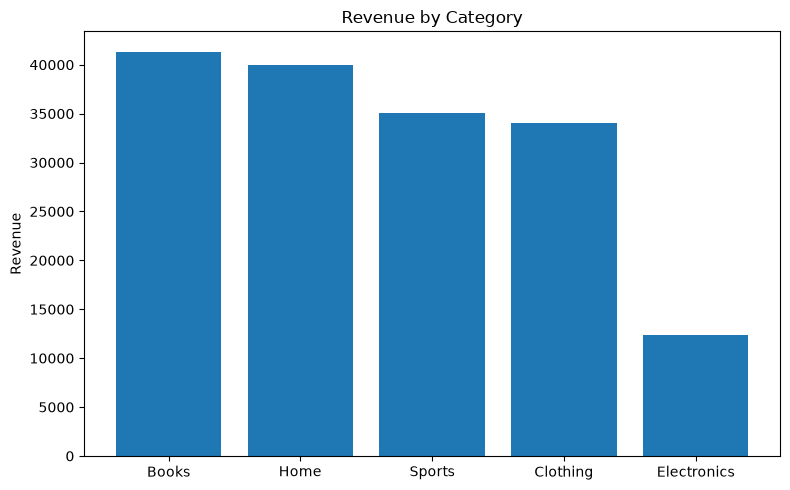

In [55]:
plt.figure(figsize=(8,5))
plt.bar(cat_rev["category"], cat_rev["revenue"])
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

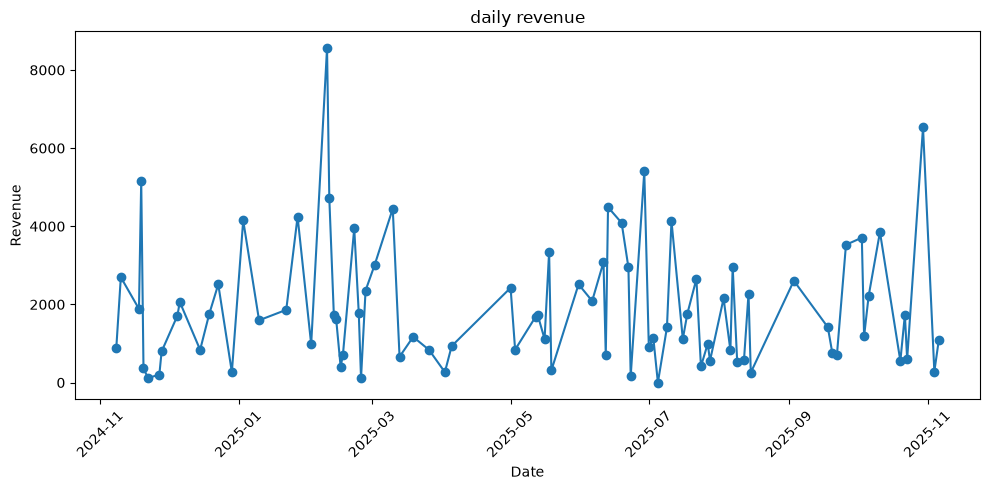

In [61]:
plt.figure(figsize=(10,5))
plt.plot(daily_rev["order_date"], daily_rev["day_rev"], marker="o")
plt.xticks(rotation=45)
plt.title("daily revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()